In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


In [5]:
bike_train = pd.read_csv("../data/bike_train.csv")

bike_train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [6]:
bike_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [7]:
# regression 여러개로  -> 제일 좋은거 사용하기
# 하이퍼 파라미터 최적화까지

df = bike_train.copy()

df["new_datatime"] = pd.to_datetime(df["datetime"])

df["year"] = df.new_datatime.apply(lambda x: x.year)
df["month"] = df.new_datatime.apply(lambda x: x.month)
df["day"] = df.new_datatime.apply(lambda x: x.day)
df["hour"] = df.new_datatime.apply(lambda x: x.hour)

df = df.drop(["datetime", "new_datatime", "casual", "registered"], axis = 1)

df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0,16,2011,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0,40,2011,1,1,1
2,1,0,0,1,9.02,13.635,80,0.0,32,2011,1,1,2
3,1,0,0,1,9.84,14.395,75,0.0,13,2011,1,1,3
4,1,0,0,1,9.84,14.395,75,0.0,1,2011,1,1,4


In [8]:
y_label = df.iloc[:, 8]
df = df.drop("count", axis = 1)
X_data = df.copy()

X_data.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0,2011,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0,2011,1,1,1
2,1,0,0,1,9.02,13.635,80,0.0,2011,1,1,2
3,1,0,0,1,9.84,14.395,75,0.0,2011,1,1,3
4,1,0,0,1,9.84,14.395,75,0.0,2011,1,1,4


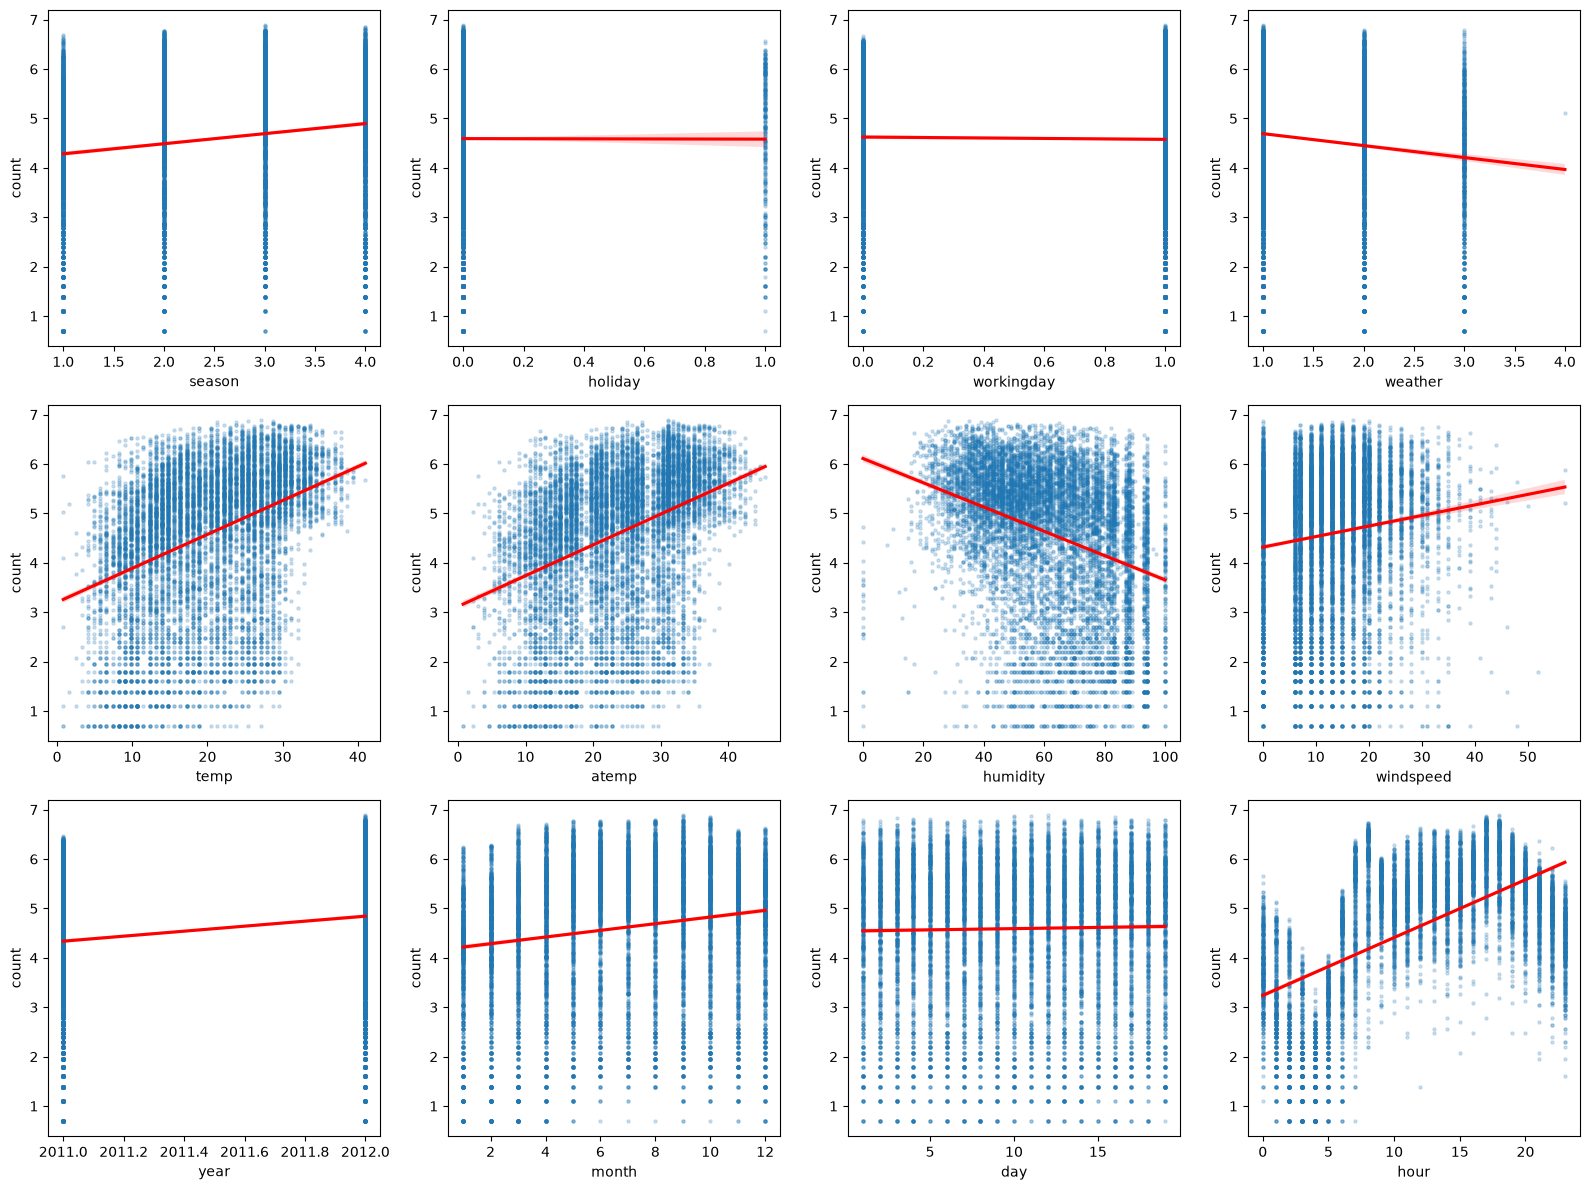

In [9]:
# 그려보고 확인하고 넘어가는게 좋음(EDA 데이터 탐색)
fig, axs = plt.subplots(figsize = (16, 12), ncols = 4, nrows = 3)
lm_features = ["season", "holiday", "workingday", "weather", "temp", "atemp", "humidity", "windspeed", "year", "month", "day", "hour"]

for i, feature in enumerate(lm_features):
    row = int(i / 4)
    col = i % 4

    sns.regplot(x = feature, y = np.log1p(y_label), data = df, ax = axs[row][col], 
                scatter_kws = {"s": 5, "alpha": 0.2, }, line_kws = {"color": "red"})

plt.tight_layout()
fig1 = plt.gcf()

In [10]:
from sklearn.model_selection import cross_val_score

def get_model_cv_prediction(model, X_data, y_target):
    neg_mse_scores = cross_val_score(model, X_data, y_target, scoring = "neg_mean_squared_error", cv = 5)
    rmse_scores = np.sqrt(-1 * neg_mse_scores)
    avg_rmse = np.mean(rmse_scores)

    print(model.__class__.__name__)
    print(avg_rmse)


In [11]:
# y(count) 스케일링 함수

# y를 log 스케일링 해주기

log_scaled_y_label = np.log1p(y_label)

X_train, X_val, y_train, y_val = train_test_split(X_data, log_scaled_y_label, test_size = 0.2, random_state = 42)

In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression

lr_reg = LinearRegression()
dt_reg = DecisionTreeRegressor(random_state = 42, max_depth = 4)
rf_reg = RandomForestRegressor(random_state = 42, n_estimators = 1000, n_jobs = -1)
gb_reg = GradientBoostingRegressor(random_state = 42, n_estimators = 1000)
xgb_reg = XGBRegressor(n_estimators = 1000)
lgbm_reg = LGBMRegressor(n_estimators = 1000)

models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgbm_reg, lr_reg]

for model in models:
    get_model_cv_prediction(model, X_data, log_scaled_y_label)

# RMSE
# DecisionTree: 139.24 -> 0.7890
# RandomForest: 74.03 -> 0.4674
# GradientBoost: 68.20 -> 0.4163
# XGB: 68.87 -> 0.4442
# LightGBM: 66.65 -> 0.4213
# LinearRegressor ? -> 1.02

# GradientBoost로 해보기

DecisionTreeRegressor
0.7890434231255824
RandomForestRegressor
0.46746590833887025
GradientBoostingRegressor
0.4163465457616361
XGBRegressor
0.44417736087346044
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 12
[LightGBM] [Info] Start training from score 4.753723
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 292
[LightGBM] [Info] Number of data points in the train set: 8709, number of used features: 12
[LightGBM] [Info] Start training from score 4.568295
[LightGBM] [Info] Auto-choosing

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

# GradientBoost 모델 학습
# train set 0.8 / validation set 0.2
gb_reg.fit(X_train, y_train)
pred = gb_reg.predict(X_val)

print(pred)

origin_pred = np.expm1(pred)

mse = mean_squared_error(y_val, pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2_SCORE:", r2_score(y_val, pred))

[4.91242739 2.51835587 5.1175816  ... 6.15471414 1.61773318 5.11491254]
MSE: 0.09585896135859373
RMSE: 0.3096109839114138
R2_SCORE: 0.9534327329531813


In [14]:
# HyperParameter Optimization

# 오래 돌아가서 우선 parameter만 얻고 주석처리
# from sklearn.model_selection import GridSearchCV

# gb_reg = GradientBoostingRegressor(random_state = 42, n_estimators = 1000)

# params = {
#     "learning_rate": [0.02, 0.04, 0.06, 0.08, 0.1],
#     "min_samples_leaf": [1, 1.5, 2, 2.5, 3],
#     "max_depth": [2, 3, 4, 5],
#     "subsample": [0.7, 0.8, 0.9]
# }

# grid_reg = GridSearchCV(gb_reg, param_grid = params, scoring = "neg_mean_squared_error", cv = 3)

# grid_reg.fit(X_train, y_train)

# print(grid_reg.best_params_, grid_reg.best_score_)

# 나중에 hyperopt로도 해보기.
# learning_rate = 0.02, max_depth = 5, min_samples_leaf = 3, subsample = 0.8
# mse -> -0.09192991548616791
# rmse = np.sqrt(-1 * mse)

In [18]:
# test셋으로 검증
# learning_rate = 0.02, max_depth = 5, min_samples_leaf = 3, subsample = 0.8

print(np.sqrt(-1 * -0.09192991548616791)) # 원래 grid_reg.best_score_인데 위에 gridsearchcv가 오래 걸리는 관계로 값으로 대체.
# RMSE = 0.30319946485138777

bike_test = pd.read_csv("../data/bike_test.csv")
df_test = bike_test.copy()

df_test["new_datatime"] = pd.to_datetime(df_test["datetime"])

df_test["year"] = df_test.new_datatime.apply(lambda x: x.year)
df_test["month"] = df_test.new_datatime.apply(lambda x: x.month)
df_test["day"] = df_test.new_datatime.apply(lambda x: x.day)
df_test["hour"] = df_test.new_datatime.apply(lambda x: x.hour)

df_test = df_test.drop(["datetime", "new_datatime"], axis = 1)

optimized_gb_reg = GradientBoostingRegressor(random_state = 42, n_estimators = 1000, learning_rate = 0.02, max_depth = 5, min_samples_leaf = 3, subsample = 0.8)

optimized_gb_reg.fit(X_train, y_train)
pred = optimized_gb_reg.predict(df_test)

print(pred)

# pred -> expm1 후 비교하기.

recall_y = np.expm1(pred).astype(int)

print(recall_y)

0.30319946485138777
[2.42314494 1.80161238 1.39654113 ... 4.93047571 4.70563575 4.32486753]
[ 10   5   3 ... 137 109  74]


In [28]:
# ndarray -> pandas 시리즈로 변환하고
# datetime이용해서 count(예측값)포함한 DF로 변환 후 csv파일 만들기.

y_predict = pd.Series(data = recall_y)

print(y_predict)
print(type(y_predict))

time = bike_test.iloc[:, 0]

# time과 y_predict를 통해서 하나의 데이터 프레임 생성
bike_predict = pd.DataFrame({"datetime": time.values, "count": y_predict.values})

# 데이터프레임을 csv로 내보내기
bike_predict.to_csv("../data/bike_predict.csv", index = False)

0        10
1         5
2         3
3         1
4         1
       ... 
6488    277
6489    184
6490    137
6491    109
6492     74
Length: 6493, dtype: int64
<class 'pandas.Series'>
